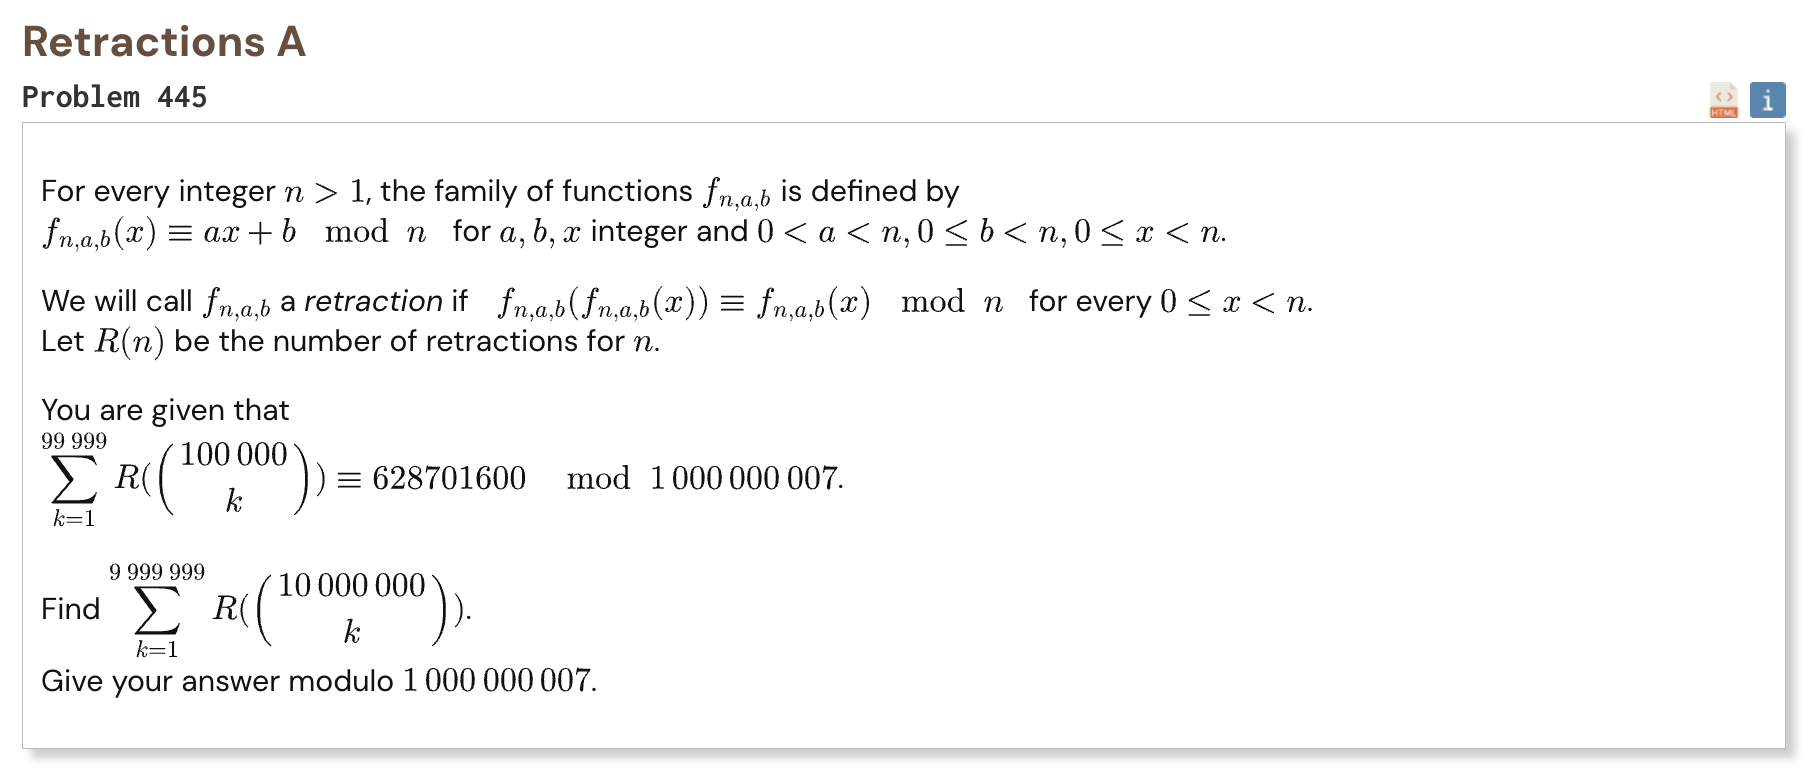

## Initial approach

-   composing the function with itself gives two conditions, n must divide a times a minus 1 and n must divide a times b
-   for every prime power dividing n, a must be either 0 or 1 modulo that whole prime power
-   this connects each valid a with a unitary divisor of n and gives the formula R of n equals the unitary divisor sum minus n
-   the unitary divisor sum is the product of 1 plus p to the power e over all prime powers in n 
-   move through the binomial coefficients with C n k equals C n k minus 1 times n minus k plus 1 divided by k
-   update the prime exponents by factoring only the new numerator and denominator instead of factoring each huge binomial coefficient
-   keep the unitary divisor product modulo 1000000007 and use symmetry so only the first half of the binomial row is processed
-   use array from the standard library to keep the large sieve and exponent tables memory efficient

In [1]:
%%time

from array import array
from math import isqrt

N = 10_000_000
MOD = 1_000_000_007

def build_spf(n):
    spf = array("I", [0]) * (n + 1)
    prime_index = array("I", [0]) * (n + 1)
    primes = array("I")

    spf[0] = 1
    spf[1] = 1
    spf[2] = 2
    primes.append(2)
    prime_index[2] = 1

    for x in range(4, n + 1, 2):
        spf[x] = 2

    limit = isqrt(n)

    for i in range(3, n + 1, 2):
        if spf[i] == 0:
            spf[i] = i
            primes.append(i)
            prime_index[i] = len(primes)

            if i <= limit:
                for j in range(i * i, n + 1, 2 * i):
                    if spf[j] == 0:
                        spf[j] = i

    return spf, primes, prime_index

def build_inverses(n):
    inv = array("I", [0]) * (n + 1)
    inv[1] = 1

    for i in range(2, n + 1):
        inv[i] = MOD - (MOD // i) * inv[MOD % i] % MOD

    return inv

def batch_inverse(values):
    size = len(values)
    result = array("I", [0]) * size
    positions = array("I")
    prefix = array("I")

    product = 1

    for i, value in enumerate(values):
        if value != 0:
            product = product * value % MOD
            positions.append(i)
            prefix.append(product)

    if not positions:
        return result

    inverse_product = pow(product, MOD - 2, MOD)

    for j in range(len(positions) - 1, -1, -1):
        i = positions[j]
        previous = prefix[j - 1] if j > 0 else 1

        result[i] = inverse_product * previous % MOD
        inverse_product = inverse_product * values[i] % MOD

    return result

spf, primes, prime_index = build_spf(N)
inverse_number = build_inverses(N)

prime_count = len(primes)

max_exponent = array("I", [0]) * prime_count
offset = array("I", [0]) * prime_count

total_terms = 0

for i in range(prime_count):
    p = primes[i]
    x = N
    exponent = 0

    while x:
        x //= p
        exponent += x

    max_exponent[i] = exponent
    offset[i] = total_terms
    total_terms += exponent

inverse_terms = array("I", [0]) * total_terms

chunk_size = 1_000_000
values = array("I")
write_position = 0

for i in range(prime_count):
    p = primes[i]
    value = p % MOD

    for _ in range(max_exponent[i]):
        values.append((value + 1) % MOD)
        value = value * p % MOD

        if len(values) == chunk_size:
            inverses = batch_inverse(values)
            inverse_terms[
                write_position:write_position + len(values)
            ] = inverses

            write_position += len(values)
            values = array("I")

if values:
    inverses = batch_inverse(values)
    inverse_terms[
        write_position:write_position + len(values)
    ] = inverses

exponents = array("I", [0]) * prime_count
prime_powers = array("I", [1]) * prime_count

unitary_product = 1
zero_factors = 0
sigma_sum = 0

middle = N // 2

for k in range(1, middle + 1):
    numerator = N - k + 1
    denominator = k

    x = numerator

    while x > 1:
        p = spf[x]
        index = prime_index[p] - 1
        count = 0

        while x > 1 and spf[x] == p:
            x //= p
            count += 1

        old_exponent = exponents[index]

        if old_exponent > 0:
            old_factor = (prime_powers[index] + 1) % MOD

            if old_factor == 0:
                zero_factors -= 1
            else:
                inverse = inverse_terms[
                    offset[index] + old_exponent - 1
                ]

                unitary_product = (
                    unitary_product * inverse
                ) % MOD

        new_exponent = old_exponent + count
        exponents[index] = new_exponent

        prime_powers[index] = (
            prime_powers[index] * pow(p, count, MOD)
        ) % MOD

        new_factor = (prime_powers[index] + 1) % MOD

        if new_factor == 0:
            zero_factors += 1
        else:
            unitary_product = (
                unitary_product * new_factor
            ) % MOD

    x = denominator

    while x > 1:
        p = spf[x]
        index = prime_index[p] - 1
        count = 0

        while x > 1 and spf[x] == p:
            x //= p
            count += 1

        old_exponent = exponents[index]
        old_factor = (prime_powers[index] + 1) % MOD

        if old_factor == 0:
            zero_factors -= 1
        else:
            inverse = inverse_terms[
                offset[index] + old_exponent - 1
            ]

            unitary_product = (
                unitary_product * inverse
            ) % MOD

        new_exponent = old_exponent - count
        exponents[index] = new_exponent

        inverse_p = inverse_number[p]

        prime_powers[index] = (
            prime_powers[index]
            * pow(inverse_p, count, MOD)
        ) % MOD

        if new_exponent > 0:
            new_factor = (prime_powers[index] + 1) % MOD

            if new_factor == 0:
                zero_factors += 1
            else:
                unitary_product = (
                    unitary_product * new_factor
                ) % MOD

    sigma_value = 0 if zero_factors else unitary_product

    if k == middle:
        sigma_sum += sigma_value
    else:
        sigma_sum += 2 * sigma_value

    sigma_sum %= MOD

binomial_sum = (pow(2, N, MOD) - 2) % MOD

result = (sigma_sum - binomial_sum) % MOD

print("Result:", result)

Result: 659104042
CPU times: user 1min 8s, sys: 716 ms, total: 1min 9s
Wall time: 1min 9s
